In [6]:
from google.colab import drive
import os

# 1. Mount the Google Drive
drive.mount('/content/drive')

# 2. Define the exact path to the shared project folder
PROJECT_ROOT = '/content/drive/MyDrive/MNIST-Project/'

# 3. Automatically create the required sub-folders if they don't exist yet
os.makedirs(os.path.join(PROJECT_ROOT, 'data'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'results'), exist_ok=True)

print("Drive successfully mounted and project directories are ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive successfully mounted and project directories are ready!


In [7]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input
from tensorflow.keras.models import Sequential

print("Loading 2D data for CNN baselines...")
data_dir = os.path.join(PROJECT_ROOT, 'data')

# Load Training Splits (and reshape to add the grayscale channel)
x_train_5k = np.load(os.path.join(data_dir, 'x_train_5k_2d.npy')).reshape(-1, 28, 28, 1)
y_train_5k = np.load(os.path.join(data_dir, 'y_train_5k.npy'))

x_train_15k = np.load(os.path.join(data_dir, 'x_train_15k_2d.npy')).reshape(-1, 28, 28, 1)
y_train_15k = np.load(os.path.join(data_dir, 'y_train_15k.npy'))

# Load Testing Data
x_test = np.load(os.path.join(data_dir, 'x_test_2d.npy')).reshape(-1, 28, 28, 1)
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

print("Data loaded successfully!")

Loading 2D data for CNN baselines...
Data loaded successfully!


In [8]:
def build_basic_cnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        Flatten(),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [9]:
print("--- Training Baseline CNN (5,000 Images) ---")
cnn_5k = build_basic_cnn()

start_time = time.time()
# We train for 5 epochs to get a quick baseline
history_5k = cnn_5k.fit(x_train_5k, y_train_5k, epochs=5, validation_data=(x_test, y_test), batch_size=32)
time_5k = time.time() - start_time

print(f"Training Time (5k): {time_5k:.2f} seconds")
print(f"Final Test Accuracy (5k): {history_5k.history['val_accuracy'][-1] * 100:.2f}%")

--- Training Baseline CNN (5,000 Images) ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.8360 - loss: 0.5668 - val_accuracy: 0.9054 - val_loss: 0.3302
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9324 - loss: 0.2353 - val_accuracy: 0.9372 - val_loss: 0.2213
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9584 - loss: 0.1428 - val_accuracy: 0.9472 - val_loss: 0.1856
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9774 - loss: 0.0909 - val_accuracy: 0.9491 - val_loss: 0.1714
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9860 - loss: 0.0587 - val_accuracy: 0.9521 - val_loss: 0.1698
Training Time (5k): 21.46 seconds
Final Test Accuracy (5k): 95.21%


In [10]:
print("--- Training Baseline CNN (15,000 Images) ---")
cnn_15k = build_basic_cnn()

start_time = time.time()
history_15k = cnn_15k.fit(x_train_15k, y_train_15k, epochs=5, validation_data=(x_test, y_test), batch_size=32)
time_15k = time.time() - start_time

print(f"Training Time (15k): {time_15k:.2f} seconds")
print(f"Final Test Accuracy (15k): {history_15k.history['val_accuracy'][-1] * 100:.2f}%")

--- Training Baseline CNN (15,000 Images) ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9065 - loss: 0.3334 - val_accuracy: 0.9576 - val_loss: 0.1558
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9678 - loss: 0.1151 - val_accuracy: 0.9660 - val_loss: 0.1104
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9809 - loss: 0.0678 - val_accuracy: 0.9700 - val_loss: 0.0951
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9879 - loss: 0.0429 - val_accuracy: 0.9727 - val_loss: 0.0873
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9927 - loss: 0.0278 - val_accuracy: 0.9724 - val_loss: 0.0917
Training Time (15k): 26.56 seconds
Final Test Accuracy (15k): 97.24%


In [11]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

data_dir = os.path.join(PROJECT_ROOT, 'data')
models_dir = os.path.join(PROJECT_ROOT, 'models')

# Load the FULL 60k 2D Dataset
print("Loading FULL 60k 2D data for Advanced CNN...")
# Reshape to add the color channel for the CNN
x_train_full_2d = np.load(os.path.join(data_dir, 'x_train_full_2d.npy')).reshape(-1, 28, 28, 1)
y_train_full = np.load(os.path.join(data_dir, 'y_train_full.npy'))

x_test_2d = np.load(os.path.join(data_dir, 'x_test_2d.npy')).reshape(-1, 28, 28, 1)
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

print(f"Data loaded successfully! Training shape: {x_train_full_2d.shape}")

Loading FULL 60k 2D data for Advanced CNN...
Data loaded successfully! Training shape: (60000, 28, 28, 1)


In [12]:
def build_advanced_cnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),

        # Block 1: Feature Extraction
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)), # Shrinks 28x28 to 14x14

        # Block 2: Deep Feature Extraction
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)), # Shrinks 14x14 to 7x7

        # Bridge to Decision Making
        Flatten(),
        Dense(128, activation='relu'),

        # Regularization
        Dropout(0.5),

        # Output Layer
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Advanced CNN Architecture defined!")

Advanced CNN Architecture defined!


In [13]:
print("--- Training Advanced CNN on FULL 60k Dataset ---")
advanced_cnn = build_advanced_cnn()

start_time = time.time()
# We are passing the full dataset here
history_advanced = advanced_cnn.fit(
    x_train_full_2d, y_train_full,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_2d, y_test)
)
training_time = time.time() - start_time

print(f"\nFinal Training Time: {training_time:.2f} seconds")
print(f"Final Test Accuracy: {history_advanced.history['val_accuracy'][-1] * 100:.2f}%")

final_model_path = os.path.join(models_dir, 'advanced_cnn.keras')
# advanced_cnn.save(final_model_path)
print(f"Final Model successfully saved to: {final_model_path}")

--- Training Advanced CNN on FULL 60k Dataset ---
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9222 - loss: 0.2513 - val_accuracy: 0.9824 - val_loss: 0.0549
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9740 - loss: 0.0865 - val_accuracy: 0.9875 - val_loss: 0.0391
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9804 - loss: 0.0675 - val_accuracy: 0.9899 - val_loss: 0.0314
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9840 - loss: 0.0547 - val_accuracy: 0.9892 - val_loss: 0.0294
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9867 - loss: 0.0444 - val_accuracy: 0.9912 - val_loss: 0.0280
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9882 - loss: 0.0379 - val_accuracy: 0.9924 - val_loss: 0.0272
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9898 - loss: 0.0332 - val_accuracy: 0.9927 - val_loss: 0.0244
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step 

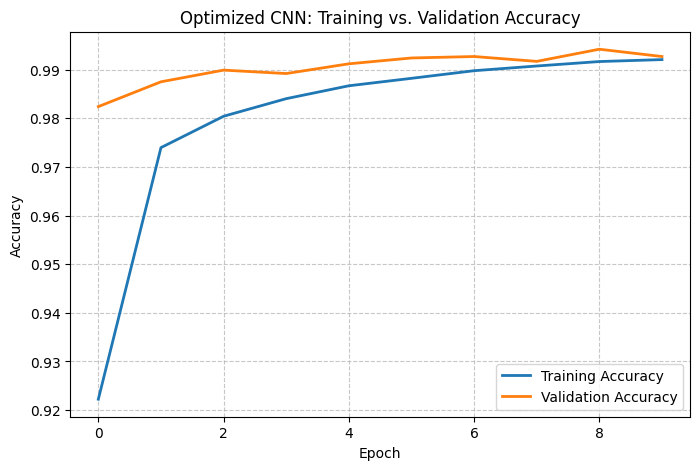

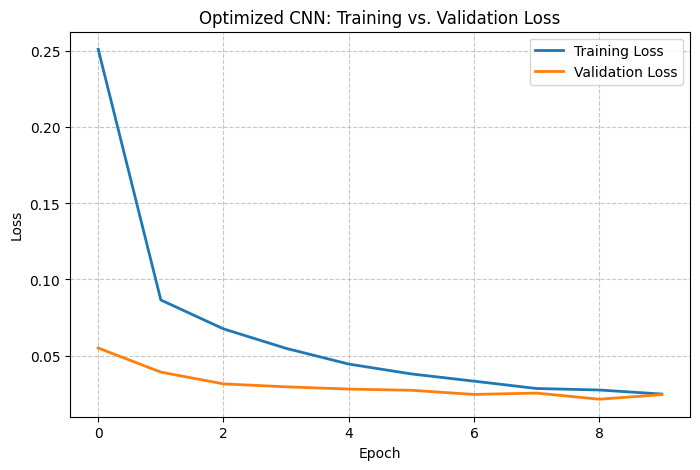

Learning Curves saved to Drive!


In [14]:
import matplotlib.pyplot as plt
import os

# 1. Plot Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(history_advanced.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_advanced.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Optimized CNN: Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(os.path.join(models_dir, '../results/cnn_accuracy_curve.png'), bbox_inches='tight')
plt.show()

# 2. Plot Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history_advanced.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_advanced.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Optimized CNN: Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(os.path.join(models_dir, '../results/cnn_loss_curve.png'), bbox_inches='tight')
plt.show()

print("Learning Curves saved to Drive!")